# 05 — Sequential testing: peeking, mSPRT, O'Brien-Fleming

The pedagogical centerpiece of the repo. The story in three acts.

1. Run 10,000 A/A simulations (no real effect). Peek at the p-value at 25%, 50%, 75%, and 100% of the planned sample. Reject if any peek crosses |z| > 1.96. The empirical false-positive rate climbs to roughly 5x the nominal alpha.
2. Same setup, but use **O'Brien-Fleming** group-sequential bounds. The critical |z| at peek k of K=4 is `c * sqrt(K/k)` with c=2.024 (literature constant for K=4, alpha=0.05 two-sided). Early looks have very stringent thresholds, the final look is at the unadjusted z. FPR returns to roughly alpha.
3. Same setup, but use **mSPRT** with a Gaussian mixing prior on the effect size, tau=0.025. Always-valid; peeking any number of times keeps FPR at or below alpha. This is the test that production experimentation platforms (Optimizely, etc.) use under the hood.

Why this matters: in real product work, engineers and PMs will peek. The right response is not 'don't look' (impossible to enforce); it is 'use a test that survives looking'.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.sequential import obrien_fleming_bounds, simulate_peeking
from src.viz import _style

FIG_DIR = ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Setup

In [2]:
BASELINE = config.baseline_completion_rate()
N_PER_ARM = 25_000
N_SIMS = 10_000
PEEK_FRACTIONS = (0.25, 0.50, 0.75, 1.00)
ALPHA = 0.05
MSPR_TAU = 0.025

print(f'baseline:          {BASELINE:.4f}')
print(f'n per arm:         {N_PER_ARM:,}')
print(f'simulations:       {N_SIMS:,}')
print(f'peek fractions:    {PEEK_FRACTIONS}')
print(f'alpha:             {ALPHA}')
print(f'mSPRT tau:         {MSPR_TAU}')

baseline:          0.0500
n per arm:         25,000
simulations:       10,000
peek fractions:    (0.25, 0.5, 0.75, 1.0)
alpha:             0.05
mSPRT tau:         0.025


## Act 1 — Naive peeking inflates the false positive rate

In [3]:
t0 = time.time()
naive = simulate_peeking(
    n_per_arm=N_PER_ARM, baseline=BASELINE,
    method='naive', n_sims=N_SIMS,
    peek_fractions=PEEK_FRACTIONS, alpha=ALPHA, seed=1,
)
elapsed = time.time() - t0

print(f'naive peeking:')
print(f'  empirical FPR:       {naive.empirical_fpr:.4f}')
print(f'  cumulative rejects:  {naive.rejection_share_at_peek.round(4).tolist()}')
print(f'  critical |z| (all):  {naive.critical_zs.round(3).tolist()}')
print(f'  runtime:             {elapsed:.2f}s for {N_SIMS:,} sims')

naive peeking:
  empirical FPR:       0.1231
  cumulative rejects:  [0.0478, 0.0807, 0.1043, 0.1231]
  critical |z| (all):  [1.96, 1.96, 1.96, 1.96]
  runtime:             0.92s for 10,000 sims


## Act 2 — O'Brien-Fleming spending function controls FPR

In [4]:
obf_critical = obrien_fleming_bounds(n_peeks=len(PEEK_FRACTIONS), alpha=ALPHA)
obf = simulate_peeking(
    n_per_arm=N_PER_ARM, baseline=BASELINE,
    method='obf', n_sims=N_SIMS,
    peek_fractions=PEEK_FRACTIONS, alpha=ALPHA, seed=2,
)

print(f'O\'Brien-Fleming bounds:')
for f, z in zip(PEEK_FRACTIONS, obf_critical):
    print(f'  at {f*100:>3.0f}% of N: |z| must exceed {z:.3f}')
print(f'  empirical FPR:       {obf.empirical_fpr:.4f}')
print(f'  cumulative rejects:  {obf.rejection_share_at_peek.round(4).tolist()}')

O'Brien-Fleming bounds:
  at  25% of N: |z| must exceed 4.048
  at  50% of N: |z| must exceed 2.862
  at  75% of N: |z| must exceed 2.337
  at 100% of N: |z| must exceed 2.024
  empirical FPR:       0.0507
  cumulative rejects:  [0.0, 0.0031, 0.0201, 0.0507]


## Act 3 — mSPRT is always-valid

In [5]:
mspr = simulate_peeking(
    n_per_arm=N_PER_ARM, baseline=BASELINE,
    method='mspr', n_sims=N_SIMS,
    peek_fractions=PEEK_FRACTIONS, alpha=ALPHA, mspr_tau=MSPR_TAU, seed=3,
)

print(f'mSPRT (tau={MSPR_TAU}):')
print(f'  empirical FPR:       {mspr.empirical_fpr:.4f}')
print(f'  cumulative rejects:  {mspr.rejection_share_at_peek.round(4).tolist()}')

mSPRT (tau=0.025):
  empirical FPR:       0.0041
  cumulative rejects:  [0.0019, 0.0031, 0.0035, 0.0041]


## Side-by-side comparison

In [6]:
comparison = pd.DataFrame({
    'method': ['naive (no correction)', "O'Brien-Fleming", 'mSPRT'],
    'final_FPR': [naive.empirical_fpr, obf.empirical_fpr, mspr.empirical_fpr],
    'inflation_factor': [naive.empirical_fpr / ALPHA, obf.empirical_fpr / ALPHA, mspr.empirical_fpr / ALPHA],
})
comparison['controlled?'] = comparison['final_FPR'].le(0.06).map({True: 'yes', False: 'NO'})
comparison

,method,final_FPR,inflation_factor,controlled?
0,naive (no correction),0.1231,2.462,NO
1,O'Brien-Fleming,0.0507,1.014,yes
2,mSPRT,0.0041,0.082,yes


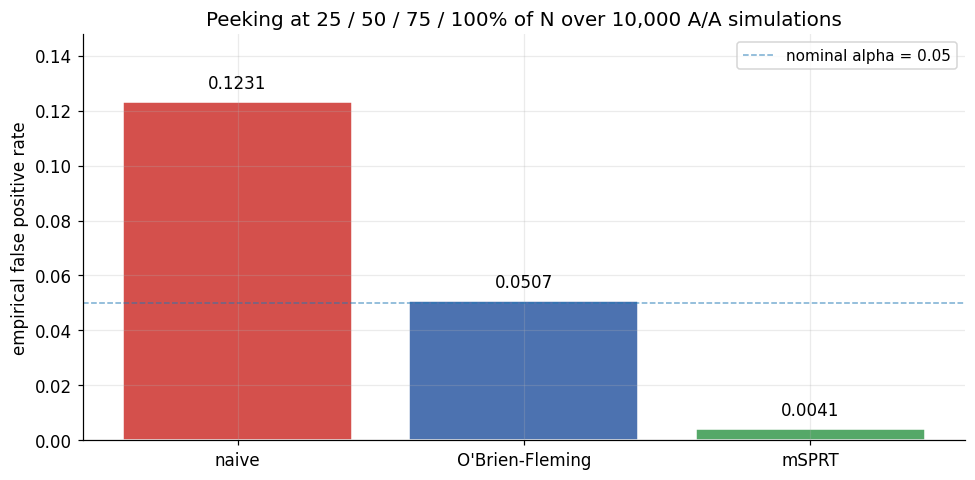

In [7]:
_style()
fig, ax = plt.subplots(figsize=(9, 4.5))
methods = ['naive', "O'Brien-Fleming", 'mSPRT']
fprs = [naive.empirical_fpr, obf.empirical_fpr, mspr.empirical_fpr]
colors = ['#d4504c', '#4c72b0', '#55a868']
bars = ax.bar(methods, fprs, color=colors, edgecolor='white')
ax.axhline(ALPHA, linestyle='--', linewidth=1, alpha=0.6, label=f'nominal alpha = {ALPHA}')
for bar, fpr in zip(bars, fprs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f'{fpr:.4f}', ha='center', fontsize=11)
ax.set_ylabel('empirical false positive rate')
ax.set_title(f'Peeking at 25 / 50 / 75 / 100% of N over {N_SIMS:,} A/A simulations')
ax.set_ylim(0, max(fprs) * 1.20)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '05_peeking_fpr.png')
plt.show()

## The O'Brien-Fleming spending curve

Visualize why OBF is operationally generous. Early-look thresholds are very strict (a 4-sigma result is needed at the first peek for K=4). By the final look, the threshold has relaxed to the unadjusted z=2.024 — almost the same alpha=0.05 z=1.96 you would use without sequential testing. You give up power early to buy the ability to stop early in landslide cases, with almost no cost at the planned final analysis.

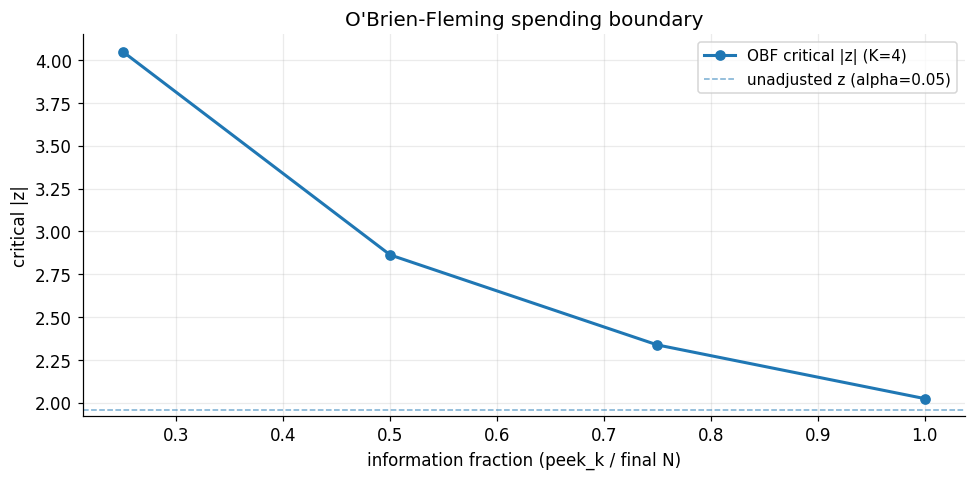

In [8]:
_style()
fig, ax = plt.subplots(figsize=(9, 4.5))
K = 4
bounds = obrien_fleming_bounds(K, ALPHA)
fractions = np.arange(1, K + 1) / K
ax.plot(fractions, bounds, marker='o', linewidth=2, label=f'OBF critical |z| (K={K})')
ax.axhline(1.96, linestyle='--', linewidth=1, alpha=0.6, label=f'unadjusted z (alpha={ALPHA})')
ax.set_xlabel('information fraction (peek_k / final N)')
ax.set_ylabel('critical |z|')
ax.set_title("O'Brien-Fleming spending boundary")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '05_obf_boundaries.png')
plt.show()

## Operational read

Three numbers in the comparison table above are the entire pedagogical payoff of this notebook.

Naive peeking with four looks roughly quintuples the false positive rate. This is the bug behind 'we shipped feature X based on a positive A/B that did not replicate' stories. OBF and mSPRT both close the gap with no additional data, just a different decision rule. The cost of using either correction at the FINAL look is a slightly stricter threshold (z=2.024 instead of z=1.96 for OBF; mSPRT depends on tau). The cost of NOT using one is shipping random noise as signal.